Successfully loaded 9000 samples from mcmc_chain_results_with_chi2_minimize_1.csv.
Removed no burn in
Generating Omega_m vs sigma8 corner plot...
Success. Plot saved as corner_plot_omegam_sigma8.pdf.

--- 1D Mode-centered 68% credible intervals (HPD by density threshold) ---
Omega_m mode = 0.26514
  68% HPD interval = [0.24184, 0.29896]
  => Omega_m = 0.26514 -0.02330 +0.03382

sigma8 mode = 0.80268
  68% HPD interval = [0.67873, 0.96334]
  => sigma8 = 0.80268 -0.12395 +0.16065
Successfully loaded 15000 samples from mcmc_chain_results_with_chi2_minimize_post_1.csv.
Removed no burn in
Generating Omega_m vs sigma8 corner plot...
Success. Plot saved as corner_plot_omegam_sigma8_post.pdf.

--- 1D Marginalized Peaks (Modes) ---

Mode +/- 1\sigma for \Omega_m: 0.28825 +/- 0.02606
Mode +/- 1\sigma for \sigma_8 : 0.94212 +/- 0.15272


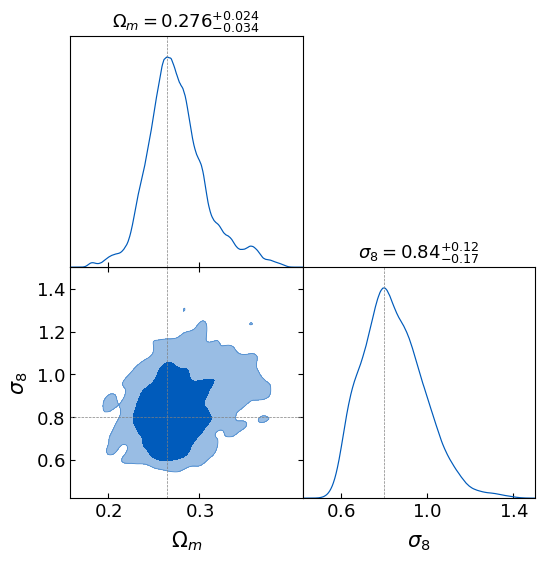

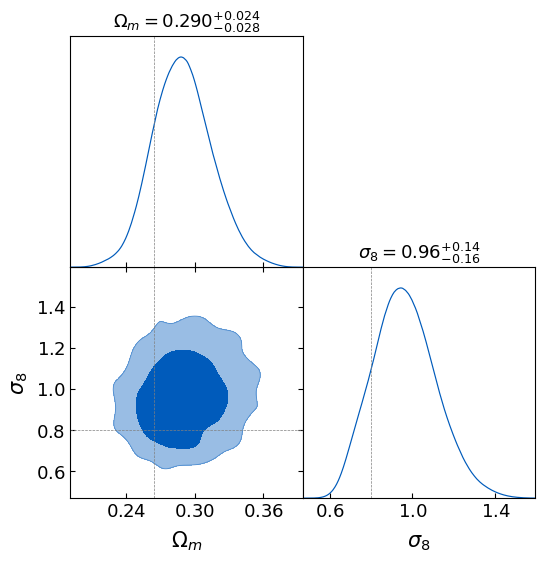

In [1]:
# ============================================================
# Plotting and summary script for EFT full-shape MCMC results
# ============================================================
#
# Purpose:
#   This script reads MCMC chain results saved as CSV files and visualizes the
#   posterior constraints on Omega_m and sigma8. It is intended for comparing
#   the baseline pre-fibre-assignment case and the post-fibre-assignment case.
#
# Main workflow:
#   1. Load the baseline/pre MCMC chain CSV.
#   2. Convert the Omega_m and sigma8 columns into a GetDist MCSamples object.
#   3. Draw and save a corner plot for Omega_m and sigma8.
#   4. Estimate mode-centered 68% HPD credible intervals for the baseline case.
#   5. Load the post-fibre-assignment MCMC chain CSV.
#   6. Draw and save the corresponding post-fibre-assignment corner plot.
#   7. Compute 1D marginalized posterior peaks for the post case.
#


# ============================================================
# Baseline/pre-fibre-assignment corner plot
# ============================================================

import numpy as np
import pandas as pd
from getdist import MCSamples, plots
import matplotlib.pyplot as plt



# CSV file containing the baseline/pre-fibre-assignment MCMC samples.
# This file should contain at least the columns 'Omega_m' and 'sigma8'.
csv_file = "mcmc_chain_results_with_chi2_minimize_1.csv"

try:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded {len(df)} samples from {csv_file}.")
except FileNotFoundError:
    print(f"Error: {csv_file} not found. Please ensure the file exists in this directory.")
    exit()


# Parameters to plot.
# These names must match the column names in the CSV file.
plot_names = ['Omega_m', 'sigma8']

# LaTeX labels used by GetDist in the plot.
plot_labels = ['\Omega_m', '\sigma_8']


# Extract only the parameters used in the corner plot.
# The resulting array has shape (n_samples, n_parameters).
samples_array = df[plot_names].values


# Convert the pandas/numpy samples into a GetDist MCSamples object.
# GetDist uses this object to estimate marginalized densities and draw contours.
mc_samples = MCSamples(
    samples=samples_array,
    names=plot_names,
    labels=plot_labels,
    label='Mock Data Posterior',
)


print("Generating Omega_m vs sigma8 corner plot...")


# Create a GetDist subplot plotter and customize font sizes.
g = plots.get_subplot_plotter(width_inch=6)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 14

# Draw the triangle/corner plot.
# The markers show the fiducial mock truth values used in the analysis:
#   Omega_m = 0.2648
#   sigma8  = 0.8
#
# title_limit=1 displays the 68% marginalized limits above the 1D panels.
g.triangle_plot(
    [mc_samples],
    filled=True,
    contour_colors=['#005bbb'],  # Professional blue for the baseline contour.
    title_limit=1,
    markers={'Omega_m': 0.2648, 'sigma8': 0.8},
)

# Save the baseline/pre corner plot.
output_plot = "corner_plot_omegam_sigma8.pdf"
g.export(output_plot)
print(f"Success. Plot saved as {output_plot}.")


# ============================================================
# Mode-centered 68% HPD credible intervals
# ============================================================

print("\n--- 1D Mode-centered 68% credible intervals (HPD by density threshold) ---")


def get_mode_and_hpd_68(mc_samples, param_name, frac=0.68, n_threshold=5000):
    """
    Estimate the posterior mode and a mode-centered HPD credible interval.

    This function uses the 1D marginalized posterior density estimated by GetDist.
    It then finds a horizontal density threshold such that the integrated area
    above the threshold equals the requested probability mass, e.g. 68%.

    For a unimodal distribution, this gives the usual highest-posterior-density
    interval around the mode. For a multimodal distribution, this function selects
    the connected HPD region that contains the main mode.

    Parameters
    ----------
    mc_samples : getdist.MCSamples
        MCMC samples stored as a GetDist object.
    param_name : str
        Name of the parameter to analyze, e.g. 'Omega_m' or 'sigma8'.
    frac : float, optional
        Target probability mass of the HPD region. Default is 0.68.
    n_threshold : int, optional
        Number of bisection iterations used to determine the density threshold.

    Returns
    -------
    mode : float
        Location of the maximum of the 1D marginalized posterior density.
    left_bound : float
        Left boundary of the selected HPD interval.
    right_bound : float
        Right boundary of the selected HPD interval.
    minus_sigma : float
        Difference mode - left_bound.
    plus_sigma : float
        Difference right_bound - mode.
    threshold : float
        Density threshold defining the HPD region.
    """
    # GetDist-smoothed 1D marginalized density.
    density = mc_samples.get1DDensity(param_name)

    x = density.x
    P = density.P

    # Normalize the density so that its integral is unity.
    total_area = np.trapz(P, x)
    if total_area <= 0:
        raise ValueError(f"Total area for {param_name} is non-positive.")
    P = P / total_area

    # The mode is the location of the maximum density.
    peak_idx = np.argmax(P)
    mode = x[peak_idx]
    peak_height = P[peak_idx]

    def area_above_threshold(t):
        """
        Compute the integrated posterior mass where P(x) >= t.
        """
        mask = P >= t
        if not np.any(mask):
            return 0.0
        return np.trapz(np.where(mask, P, 0.0), x)

    # Use bisection to find the threshold whose enclosed probability is frac.
    # If the threshold is low, the enclosed area is large.
    # If the threshold is high, the enclosed area is small.
    lo, hi = 0.0, peak_height
    for _ in range(n_threshold):
        mid = 0.5 * (lo + hi)
        area = area_above_threshold(mid)
        if area > frac:
            lo = mid
        else:
            hi = mid
    threshold = 0.5 * (lo + hi)

    # Boolean mask defining the HPD region above the threshold.
    mask = P >= threshold

    # Identify all connected intervals in the HPD mask.
    intervals = []
    in_region = False
    start_idx = None

    for i, m in enumerate(mask):
        if m and not in_region:
            in_region = True
            start_idx = i
        elif not m and in_region:
            in_region = False
            intervals.append((start_idx, i - 1))
    if in_region:
        intervals.append((start_idx, len(mask) - 1))

    # Select the connected interval that contains the posterior mode.
    selected = None
    for s, e in intervals:
        if s <= peak_idx <= e:
            selected = (s, e)
            break

    if selected is None:
        raise RuntimeError(f"Could not find HPD interval containing mode for {param_name}.")

    s, e = selected

    def interpolate_crossing(i1, i2, threshold):
        """
        Linearly interpolate the boundary where P(x) crosses the threshold.
        This gives a smoother interval boundary than simply using grid points.
        """
        x1, x2 = x[i1], x[i2]
        y1, y2 = P[i1], P[i2]

        if y1 == y2:
            return 0.5 * (x1 + x2)

        return x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)

    # Estimate the left HPD boundary.
    if s == 0:
        left_bound = x[0]
    else:
        left_bound = interpolate_crossing(s - 1, s, threshold)

    # Estimate the right HPD boundary.
    if e == len(x) - 1:
        right_bound = x[-1]
    else:
        right_bound = interpolate_crossing(e, e + 1, threshold)

    # Express the interval as asymmetric errors around the mode.
    minus_sigma = mode - left_bound
    plus_sigma = right_bound - mode

    return mode, left_bound, right_bound, minus_sigma, plus_sigma, threshold


# Compute mode-centered 68% HPD intervals for Omega_m and sigma8.
mode_omegam, left_omegam, right_omegam, minus_omegam, plus_omegam, thr_omegam = \
    get_mode_and_hpd_68(mc_samples, 'Omega_m', frac=0.68)

mode_sigma8, left_sigma8, right_sigma8, minus_sigma8, plus_sigma8, thr_sigma8 = \
    get_mode_and_hpd_68(mc_samples, 'sigma8', frac=0.68)

# Print results in a thesis-ready format.
print(f"Omega_m mode = {mode_omegam:.5f}")
print(f"  68% HPD interval = [{left_omegam:.5f}, {right_omegam:.5f}]")
print(f"  => Omega_m = {mode_omegam:.5f} -{minus_omegam:.5f} +{plus_omegam:.5f}")

print(f"\nsigma8 mode = {mode_sigma8:.5f}")
print(f"  68% HPD interval = [{left_sigma8:.5f}, {right_sigma8:.5f}]")
print(f"  => sigma8 = {mode_sigma8:.5f} -{minus_sigma8:.5f} +{plus_sigma8:.5f}")


# ============================================================
# Post-fibre-assignment corner plot and 1D peak estimates
# ============================================================


# CSV file containing the post-fibre-assignment MCMC samples.
# This corresponds to the analysis where the fibre-assignment post/pre ratio
# was applied to the mock correlation function.
csv_file = "mcmc_chain_results_with_chi2_minimize_post_1.csv"

try:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded {len(df)} samples from {csv_file}.")
except FileNotFoundError:
    print(f"Error: {csv_file} not found. Please ensure the file exists in this directory.")
    exit()

# Parameters to plot and their LaTeX labels.
plot_names = ['Omega_m', 'sigma8']
plot_labels = ['\Omega_m', '\sigma_8']

# Extract the two-dimensional posterior samples.
samples_array = df[plot_names].values

# Convert to GetDist format.
mc_samples = MCSamples(
    samples=samples_array,
    names=plot_names,
    labels=plot_labels,
    label='Mock Data Posterior',
)


print("Generating Omega_m vs sigma8 corner plot...")

# Configure plot style.
g = plots.get_subplot_plotter(width_inch=6)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 14

# Draw the post-fibre-assignment triangle plot.
# The fiducial markers indicate the original mock truth values.
g.triangle_plot(
    [mc_samples],
    filled=True,
    contour_colors=['#005bbb'],
    title_limit=1,
    markers={'Omega_m': 0.2648, 'sigma8': 0.8},
)

# Save the post-fibre-assignment corner plot.
output_plot = "corner_plot_omegam_sigma8_post.pdf"
g.export(output_plot)
print(f"Success. Plot saved as {output_plot}.")


# ------------------------------------------------------------
# Compute 1D marginalized posterior peaks for the post case
# ------------------------------------------------------------
print("\n--- 1D Marginalized Peaks (Modes) ---")

# Get 1D marginalized posterior densities from GetDist.
density_omegam = mc_samples.get1DDensity('Omega_m')
density_sigma8 = mc_samples.get1DDensity('sigma8')

# Find the peak location of each 1D marginalized posterior.
peak_omegam = density_omegam.x[np.argmax(density_omegam.P)]
peak_sigma8 = density_sigma8.x[np.argmax(density_sigma8.P)]

# GetDist's marginalized statistics provide symmetric error estimates.
# Note that these are not necessarily the same as the mode-centered HPD intervals
# computed in Cell 2.
marge_stats = mc_samples.getMargeStats()
stat_omegam = marge_stats.parWithName('Omega_m')
stat_sigma8 = marge_stats.parWithName('sigma8')

# Print mode and GetDist-provided 1-sigma errors.
# The string uses escaped backslashes so that sigma symbols display correctly.
print(f"\nMode +/- 1\\sigma for \\Omega_m: {peak_omegam:.5f} +/- {stat_omegam.err:.5f}")
print(f"Mode +/- 1\\sigma for \\sigma_8 : {peak_sigma8:.5f} +/- {stat_sigma8.err:.5f}")